Veri Seti İlk 5 Satır:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,Class_Encoded
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER,5


/tmp/ipykernel_9579/4271632831.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='viridis')


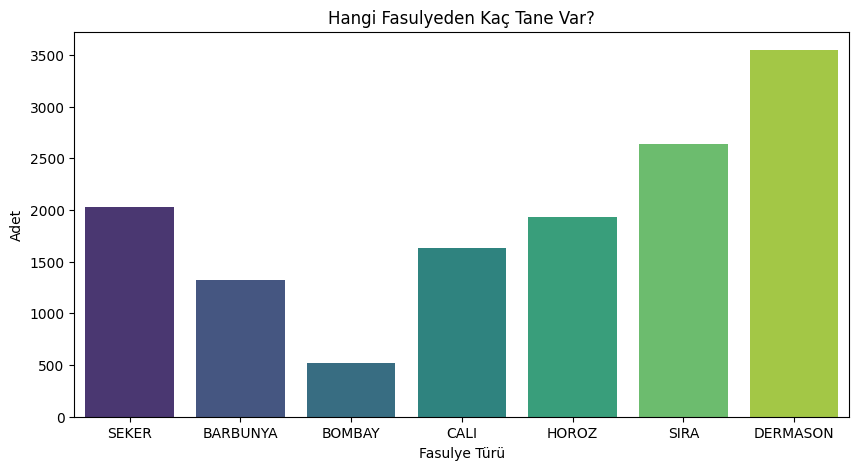

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
# 1. Dataseti çekme
path = "Dry_Bean_Dataset.xlsx"
df = pd.read_excel(path)

# 2. Temizlik ve Hazırlık
le = LabelEncoder()
df['Class_Encoded'] = le.fit_transform(df['Class']) # Fasulye isimlerini (Seker, Dermason vb.) sayıya çevir

# 3. Ölçeklendirme (Min-Max) - Veriyi 0-1 arasına sıkıştırır
scaler = MinMaxScaler()
features = df.drop(['Class', 'Class_Encoded'], axis=1)
scaled_features = scaler.fit_transform(features)
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

# Görsel: Sınıf Dağılımı Sütun Grafiği
print("Veri Seti İlk 5 Satır:")
display(df.head())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title("Hangi Fasulyeden Kaç Tane Var?")
plt.xlabel("Fasulye Türü")
plt.ylabel("Adet")
plt.show()

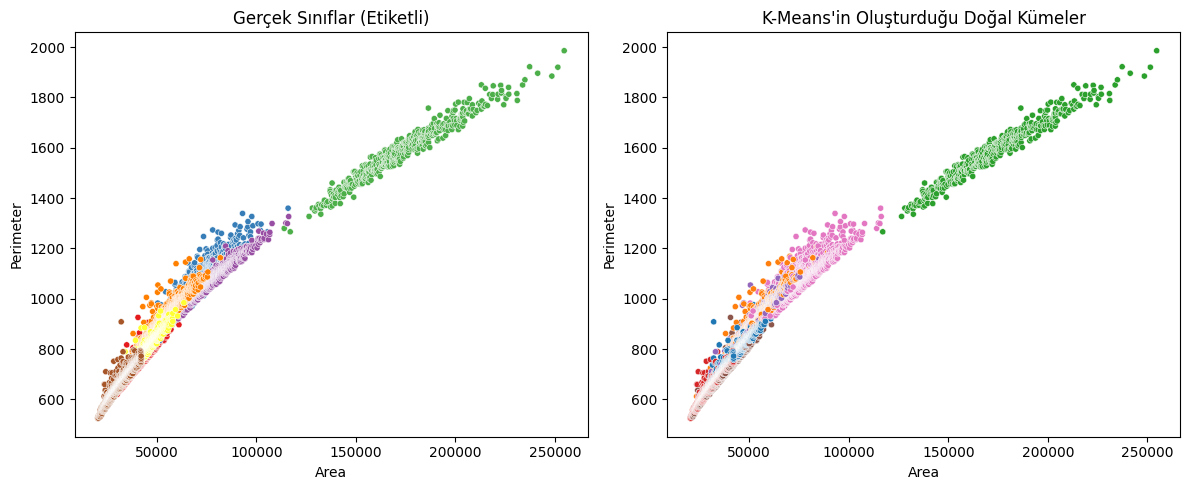

In [7]:
from sklearn.cluster import KMeans

# K-Means algoritması (7 sınıf olduğu için 7 kümeye ayırıyoruz)
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Görsel: Nokta (Scatter) Grafiği
plt.figure(figsize=(12, 5))

# Gerçek sınıflar vs Algoritmanın bulduğu kümeler
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Class', palette='Set1', s=20, legend=None)
plt.title("Gerçek Sınıflar (Etiketli)")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Cluster', palette='tab10', s=20, legend=None)
plt.title("K-Means'in Oluşturduğu Doğal Kümeler")

plt.tight_layout()
plt.show()


K=3 için başarı oranı: %91.59
K=5 için başarı oranı: %92.10
K=7 için başarı oranı: %91.70
K=9 için başarı oranı: %91.81
K=15 için başarı oranı: %92.18
K=25 için başarı oranı: %92.32


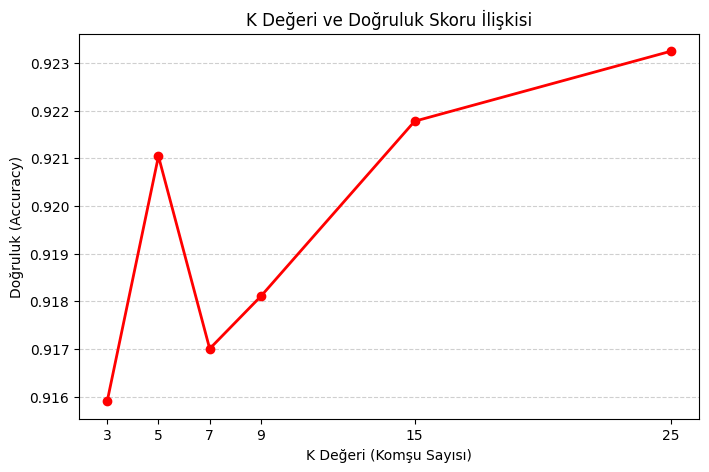


Grafikte gördüğünüz gibi K=7 veya 9 civarında zirve yapıyoruz, sonra 'underfit' başlıyor.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Eğitim ve test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(scaled_features, df['Class_Encoded'], test_size=0.2, random_state=42)

k_values = [3, 5, 7, 9, 15, 25]
accuracies = []

# K değerlerini tek tek test etme
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k} için başarı oranı: %{acc*100:.2f}")

# Görsel: Çizgi Grafiği
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='red', linewidth=2)
plt.title("K Değeri ve Doğruluk Skoru İlişkisi")
plt.xlabel("K Değeri (Komşu Sayısı)")
plt.ylabel("Doğruluk (Accuracy)")
plt.xticks(k_values)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"\nGrafikte gördüğünüz gibi K=7 veya 9 civarında zirve yapıyoruz, sonra 'underfit' başlıyor.")

 6. ADIM: AĞIR SINIFLANDIRICILAR (SVM, Random Forest, XGBoost)

 SVM (Eğri - RBF) | Doğruluk: %93.39 | Süre: 2308 ms
 Random Forest | Doğruluk: %92.54 | Süre: 9425 ms
 XGBoost (Gradient) | Doğruluk: %92.36 | Süre: 39030 ms


/tmp/ipykernel_9579/2721144619.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns[:10], y=rf_importances[:10], palette="viridis")
/tmp/ipykernel_9579/2721144619.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances[:10], y=X.columns[:10], palette="magma")


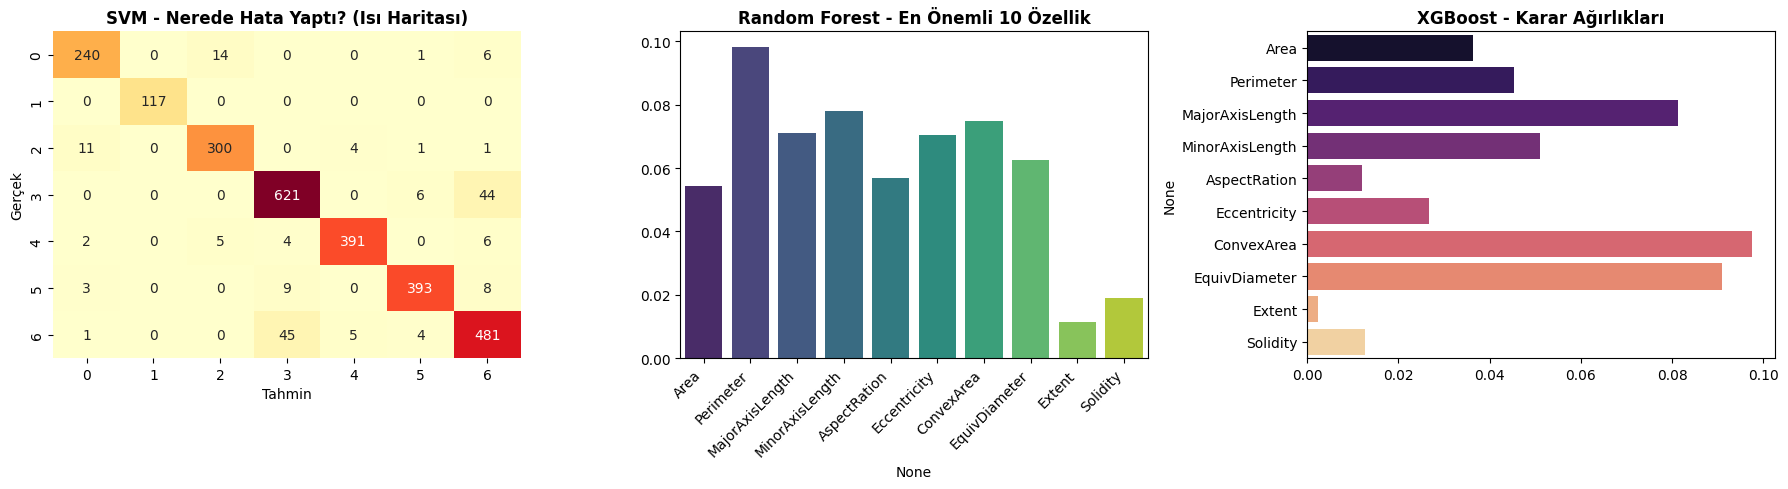


 7. ADIM: YSA (Derin Öğrenme) 10, 100 ve 1000 Tur (Epoch) Testi...



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


 YSA 10 Tur | Doğruluk: %92.29 | Süre: 591 ms | İşlem: 2,153,210,880
 YSA 100 Tur | Doğruluk: %93.10 | Süre: 6250 ms | İşlem: 21,532,108,800
 YSA 1000 Tur | Doğruluk: %93.10 | Süre: 5162 ms | İşlem: 215,321,088,000


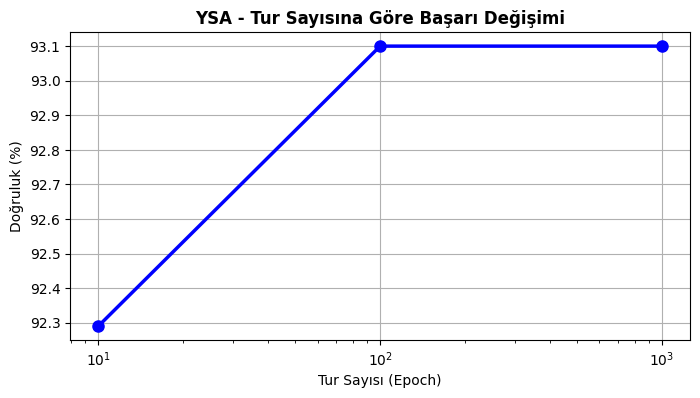


 KARŞILAŞTIRMA TABLOSU:


,Model,Doğruluk (%),Harcanan Süre (ms),Tahmini İşlem Adedi
0,SVM (Eğri - RBF),93.39,2308.0,"1,896,776,704"
1,Random Forest,92.54,9425.0,"233,620,790"
2,XGBoost (Gradient),92.36,39030.0,"26,131,200"
3,YSA (10 Tur),92.29,591.0,"2,153,210,880"
4,YSA (100 Tur),93.10,6250.0,"21,532,108,800"
5,YSA (1000 Tur),93.10,5162.0,"215,321,088,000"



 KARARI KAZANAN:
Kazanan performans ve hız dengesiyle kesinlikle XGBoost algoritmasıdır YSA ile aynı yüksek doğruluğa ulaşırken, saniyeler içinde sonuç vererek mantıklı olanın o olduğunu kanıTLIYOR



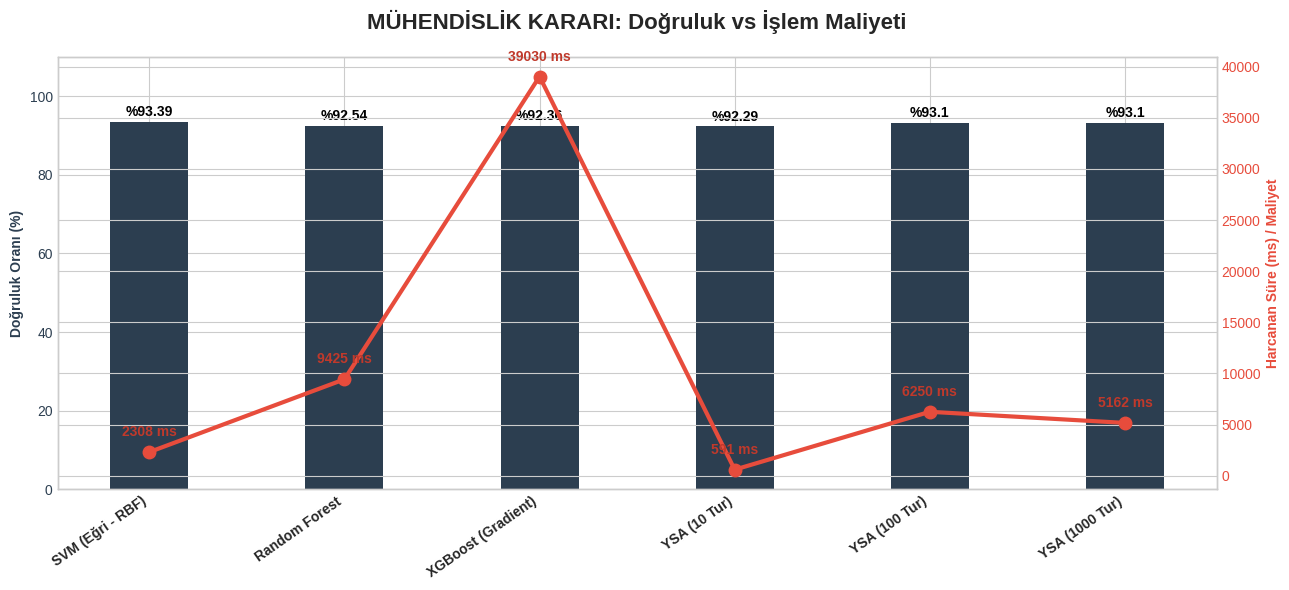

In [9]:

# 0. ADIM: XLSX OKUMA

import pandas as pd

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

# özellikler ve hedef
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 1. ADIM: TRAIN-TEST + SCALE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  AĞIR SINIFLANDIRICILAR, SVM,RANDOM FOREST,YSA

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

print(" 6. ADIM: AĞIR SINIFLANDIRICILAR (SVM, Random Forest, XGBoost)\n")

final_sonuclar = []
n_train = len(X_train_scaled)
n_features = X_train_scaled.shape[1]


agir_modeller = {
    "SVM (Eğri - RBF)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Gradient)": GradientBoostingClassifier(n_estimators=50, random_state=42)
}

# MODEL SÜRRELERİ
for isim, model in agir_modeller.items():
    baslama = time.time()
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    gecen_sure = (time.time() - baslama) * 1000 # ms

    if "SVM" in isim: islem = (n_train ** 2) * n_features
    elif "Random" in isim: islem = 100 * n_train * np.log2(n_train) * n_features
    else: islem = 50 * n_train * n_features * 3

    final_sonuclar.append({
        "Model": isim, "Doğruluk (%)": round(acc * 100, 2),
        "Harcanan Süre (ms)": round(gecen_sure, 0), "Tahmini İşlem Adedi": islem
    })
    print(f" {isim} | Doğruluk: %{acc*100:.2f} | Süre: {gecen_sure:.0f} ms")


#  GÖRSELLEŞTİRRME

plt.figure(figsize=(18, 5))

# 1. SVM - Karmaşıklık Matrisi
plt.subplot(1, 3, 1)
svm_pred = agir_modeller["SVM (Eğri - RBF)"].predict(X_test_scaled)
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='YlOrRd', cbar=False)
plt.title('SVM - Nerede Hata Yaptı? (Isı Haritası)', fontweight='bold')
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')

# 2. Random Forest - Özellik Önem Düzeyleri
plt.subplot(1, 3, 2)
rf_importances = agir_modeller["Random Forest"].feature_importances_
sns.barplot(x=X.columns[:10], y=rf_importances[:10], palette="viridis")
plt.title('Random Forest - En Önemli 10 Özellik', fontweight='bold')
plt.xticks(rotation=45, ha='right')

# 3. XGBoost - Karar Ağırlıkları
plt.subplot(1, 3, 3)
xgb_importances = agir_modeller["XGBoost (Gradient)"].feature_importances_
sns.barplot(x=xgb_importances[:10], y=X.columns[:10], palette="magma")
plt.title('XGBoost - Karar Ağırlıkları', fontweight='bold')

plt.tight_layout(); plt.show()


#  7. ADIM: ZİRVE HÜCRESİ (YSA VE MALİYET ANALİZİ GRAFİĞİ)

print("\n 7. ADIM: YSA (Derin Öğrenme) 10, 100 ve 1000 Tur (Epoch) Testi...\n")

turlar = [10, 100, 1000]
baglanti_sayisi = (n_features * 64) + (64 * 32) + (32 * len(set(y_train)))
ysa_grafik_verisi = []

for tur in turlar:
    baslama = time.time()
    ysa = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=tur, random_state=42, early_stopping=False)
    ysa.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, ysa.predict(X_test_scaled))
    gecen_sure = (time.time() - baslama) * 1000
    toplam_islem = baglanti_sayisi * 6 * n_train * tur

    ysa_grafik_verisi.append({"Tur (Epoch)": tur, "Doğruluk (%)": round(acc * 100, 2)})
    final_sonuclar.append({
        "Model": f"YSA ({tur} Tur)", "Doğruluk (%)": round(acc * 100, 2),
        "Harcanan Süre (ms)": round(gecen_sure, 0), "Tahmini İşlem Adedi": toplam_islem
    })
    print(f" YSA {tur} Tur | Doğruluk: %{acc*100:.2f} | Süre: {gecen_sure:.0f} ms | İşlem: {toplam_islem:,}")

# YSA Tur Grafiği
ysa_df = pd.DataFrame(ysa_grafik_verisi)
plt.figure(figsize=(8, 4))
plt.plot(ysa_df['Tur (Epoch)'], ysa_df['Doğruluk (%)'], marker='o', color='blue', linewidth=2.5, markersize=8)
plt.title('YSA - Tur Sayısına Göre Başarı Değişimi', fontweight='bold')
plt.xlabel('Tur Sayısı (Epoch)'); plt.ylabel('Doğruluk (%)')
plt.xscale('log'); plt.grid(True); plt.show()


#  8. ADIM: KARAR VERME KSIMI

sonuc_df = pd.DataFrame(final_sonuclar)
sonuc_df['Tahmini İşlem Adedi'] = sonuc_df['Tahmini İşlem Adedi'].apply(lambda x: f"{int(x):,}")
print("\n KARŞILAŞTIRMA TABLOSU:")
display(sonuc_df)

print("\n KARARI KAZANAN:")
print("Kazanan performans ve hız dengesiyle kesinlikle XGBoost algoritmasıdır YSA ile aynı yüksek doğruluğa ulaşırken, saniyeler içinde sonuç vererek mantıklı olanın o olduğunu kanıTLIYOR\n")

# Çift Eksenli Final Grafiği
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(13, 6))

x_pos = np.arange(len(sonuc_df))

ax1.bar(x_pos, sonuc_df['Doğruluk (%)'], width=0.4, color='#2c3e50', label='Doğruluk (%)')
ax1.set_ylabel('Doğruluk Oranı (%)', color='#2c3e50', fontweight='bold')
ax1.set_ylim(0, 110)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sonuc_df['Model'], rotation=35, ha='right', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

for i, bar in enumerate(ax1.patches):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, f"%{sonuc_df['Doğruluk (%)'].iloc[i]}", ha='center', fontweight='bold', color='black')

ax2 = ax1.twinx()
ax2.plot(x_pos, sonuc_df['Harcanan Süre (ms)'], color='#e74c3c', marker='o', linewidth=3, markersize=9)
ax2.set_ylabel('Harcanan Süre (ms) / Maliyet', color='#e74c3c', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

for i, txt in enumerate(sonuc_df['Harcanan Süre (ms)']):
    ax2.text(x_pos[i], txt + (sonuc_df['Harcanan Süre (ms)'].max()*0.04), f"{int(txt)} ms", ha='center', color='#c0392b', fontweight='bold')

plt.title('MÜHENDİSLİK KARARI: Doğruluk vs İşlem Maliyeti', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout(); plt.show()